In [1]:
import neptune as neptune
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker

# from misc import (
#     plot_module_grid,
#     plot_multiple_modules,
#     get_steps_from_first_run,
#     pivot_dict,
#     plot_loss_vs_lr,
# )

## Neptune

In [2]:
# def get_neptune_table(tags, negative_tags=None, columns=None):
#     """
#     Fetches a Neptune runs table filtered by tags and returns it as a pandas DataFrame.
#
#     Parameters:
#     - tags (list): List of tags to filter the runs.
#     - negative_tags (list, optional): List of tags to exclude from the runs.
#     - columns (list, optional): Additional columns to include in the runs table.
#
#     Returns:
#     - pandas.DataFrame: The runs table with the specified filters and columns.
#     """
#
#     # Initialize the Neptune project
#     project = neptune.init_project(
#         project="pmtest/llm-random",
#         mode="read-only",
#         api_token=os.environ["NEPTUNE_API_TOKEN"],
#     )
#
#     # Fetch the runs table with the specified tags and columns
#     runs_table = project.fetch_runs_table(tag=tags, columns=columns).to_pandas()
#
#     # Ensure 'sys/tags' is a list for each run
#     # print(f"runs_table: {runs_table}")
#     runs_table["sys/tags"] = runs_table["sys/tags"].apply(
#         lambda x: x.split(",") if isinstance(x, str) else x
#     )
#
#     # Exclude runs containing any of the negative tags
#     if negative_tags:
#         for neg_tag in negative_tags:
#             runs_table = runs_table[
#                 ~runs_table["sys/tags"].apply(lambda x: neg_tag in x)
#             ]
#
#     print(f"Table downloaded\nShape: {runs_table.shape}")
#     return runs_table

In [3]:
# os.environ
os.environ["NEPTUNE_API_TOKEN"]  ="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI5MmNhMDBkMi00ZWI4LTQ5ZGUtYmJmYy02MmI3YjlhNWY1ZDkifQ=="

In [5]:
project = neptune.init_project(
        project="pmtest/llm-random",
        mode="read-only",
        api_token=os.environ["NEPTUNE_API_TOKEN"],
    )

# Fetch the runs table with the specified tags and columns
runs_table = project.fetch_runs_table(tag="diff_gda_adapters_grid_fix").to_pandas()

# Ensure 'sys/tags' is a list for each run
# print(f"runs_table: {runs_table}")
runs_table["sys/tags"] = runs_table["sys/tags"].apply(
    lambda x: x.split(",") if isinstance(x, str) else x
)

print(f"Table downloaded\nShape: {runs_table.shape}")
runs_table

NeptuneConnectionLostException: 
[95m
----NeptuneConnectionLostException---------------------------------------------------------
[0m
The connection to the Neptune server was lost.
If you are using the asynchronous (default) connection mode, Neptune continues to locally track your metadata and continuously tries to re-establish a connection to the Neptune servers.
If the connection is not re-established, you can upload your data later with the Neptune Command Line Interface tool:
    [95mneptune sync -p workspace_name/project_name[0m

What should I do?
    - Check if your computer is connected to the internet.
    - If your connection is unstable, consider working in offline mode:
        [96mrun = neptune.init_run(mode="offline")[0m

You can find detailed instructions on the following doc pages:
    - https://docs.neptune.ai/api/connection_modes/#offline-mode
    - https://docs.neptune.ai/api/neptune_sync/

You may also want to check the following docs page:
    - https://docs.n

In [7]:
df#[(df['adapter'] == 'lora') | (df['adapter'] == 'multiplicative')]

,id,adapter,neg_heads,permutation,loss,accuracy,learning_rate
0,LLMRANDOM-32361,multiadd,6,roll_interleave,3.141656,0.407618,0.002
1,LLMRANDOM-32360,multiadd,6,repeat_roll,3.127453,0.409036,0.002
2,LLMRANDOM-32359,multiadd,6,roll_repeat,3.177062,0.403787,0.002
3,LLMRANDOM-32358,multiadd,6,flip_interleave,3.129953,0.408924,0.002
4,LLMRANDOM-32356,multiadd,6,flip_repeat,3.130250,0.408962,0.002
...,...,...,...,...,...,...,...
588,LLMRANDOM-31544,none,12,flip_repeat,NaN,NaN,0.002
591,LLMRANDOM-31541,none,12,repeat,NaN,NaN,0.002
593,LLMRANDOM-31536,none,12,roll_repeat,NaN,NaN,0.002
594,LLMRANDOM-31533,none,12,flip_repeat,NaN,NaN,0.002


In [5]:
df = runs_table[["sys/id", "args/diff_transformer_adapter_type", "args/n_negative_heads", "args/diff_transformer_negative_heads_permutation", "loss", "accuracy", "args/learning_rate"]]#.groupby('args/diff_transformer_negative_heads_permutation')['loss'].agg(['mean', 'count'])
df = df.rename(columns={"sys/id": "id", "args/diff_transformer_adapter_type": "adapter", "args/n_negative_heads": "neg_heads", "args/diff_transformer_negative_heads_permutation": "permutation", "args/learning_rate": "learning_rate"})
df = df[(1.9e-3 < df['learning_rate']) & (df['learning_rate'] < 2.1e-3)]
# df = df[df['permutation'] == 'repeat']
df.dropna().groupby(['adapter', 'neg_heads'])['loss'].agg(['mean','count'])

mean  count
adapter        neg_heads                 
additive       1          3.131915      7
               2          3.125324      7
               3          3.136614      7
               4          3.131029      7
               6          3.134210      7
               12         3.133098      7
identity       1          3.133717      7
               2          3.137964      7
               3          3.138556      7
               4          3.139154      7
               6          3.146518      7
               12         3.141371      7
lora           1          3.146531      1
               2          3.133722      5
               3          3.134576      7
               4          3.126978      7
               6          3.132013      7
               12         3.116042      3
multiadd       1          3.481490      6
               2          3.129705      7
               3          3.134895      7
               4          3.135687      7
               6          3.142085      7
               12         3.122828      3
multiplicative 1          3.130616      7
               2          3.131496      7
               3          3.131170      7
               4          3.132855      7
               6          3.132143      7
               12         3.130567      7
none           1          3.163438      1
               2          3.176520      4
               3          3.160121      7
               4          3.167317      7
               6          3.166424      7
               12         3.172729      3

In [142]:
df1 = df[(df['neg_heads'] == 1 & ((df['adapter'] == "lora") | (df['adapter'] == "none"))) | ((df['neg_heads'] == 12) & ((df['adapter'] == "multiadd") | (df['adapter'] == "lora"))) | ((df['neg_heads'] == 2) & ((df['adapter'] == 'none') | (df['adapter'] == 'lora')))]
merged_df = df.merge(df1, on='id', how='left', indicator=True)

# Filter rows that are only in df
df2 = merged_df[merged_df['_merge'] == 'left_only'].drop(columns=['_merge'])[["id", 'adapter_x', 'neg_heads_x', 'permutation_x', 'loss_x', 'accuracy_x']]

df1.groupby(['permutation'])['loss'].agg(['mean', 'count'])

,mean,count
permutation,,
flip_repeat,3.131341,6
interleave,3.156482,6
repeat,3.151570,18
repeat_roll,3.160029,6
roll_interleave,3.156425,5
roll_repeat,3.145013,12


In [152]:
df_anova = df.groupby(['adapter'])['loss'].agg(['mean', 'count', 'var'])
df_anova

,mean,count,var
adapter,,,
additive,3.140036,124,0.000130
identity,3.143971,126,0.000128
lora,3.137796,88,0.000150
multiadd,3.162032,109,0.040564
multiplicative,3.139200,125,0.000132
none,3.171764,89,0.000108


In [150]:
group1 = df[df['permutation'] == 'repeat']['loss'].to_numpy()
group1

array([3.14701562, 3.12929688, 3.14539063, 3.12510938, 3.13429687,
       3.12132812, 3.13139062, 3.15225   , 3.12632813, 3.13535938,
       3.12439063, 3.11578125, 3.123     , 3.12765625, 3.15404688,
              nan, 3.1319375 , 3.14778125, 3.14792188, 3.159625  ,
       3.13848437, 3.1365    , 3.1255    , 3.13182813, 3.13314062,
       3.15114063, 3.15367188, 3.12532812, 3.1208125 , 3.12459375,
       3.11785938, 3.12923437, 3.12971875, 3.15104688, 3.15279687,
       3.12309375, 3.1263125 , 3.12951562, 3.13198438, 3.15276562,
       3.1535    , 3.14935937, 3.14782813, 3.1384375 , 3.12253125,
       3.13570313, 3.125125  , 3.15765625, 3.14942187, 3.14542187,
       3.13279687, 3.12025   , 3.11425   , 3.12939063, 3.12923437,
       3.15159375, 3.13303125, 3.15575   , 3.15101562, 3.13675   ,
       3.16421875, 3.16021875, 3.13651562, 3.16182812, 3.12923437,
       3.14134375, 3.13651562, 3.158125  , 3.13720313, 3.14334375,
       3.15370312, 3.14928125, 3.1516875 , 3.1390625 , 3.15512

In [154]:
means = df_anova['mean'].to_numpy()
sizes = df_anova['count'].to_numpy()
vars = df_anova['var'].to_numpy()

In [155]:
from scipy.stats import f

overall_mean = np.sum(np.array(means) * np.array(sizes)) / np.sum(sizes)

# Calculate the sum of squares between groups (SSB)
SSB = np.sum(sizes * (np.array(means) - overall_mean) ** 2)

# Calculate the sum of squares within groups (SSW)
SSW = np.sum((sizes - 1) * np.array(vars))

# Degrees of freedom
df_between = len(means) - 1
df_within = np.sum(sizes) - len(means)

# Mean squares
MSB = SSB / df_between
MSW = SSW / df_within

# F-statistic
F = MSB / MSW

# p-value
p_value = 1 - f.cdf(F, df_between, df_within)

print(f"F-statistic: {F}")
print(f"p-value: {p_value}")

F-statistic: 2.9555772016660513
p-value: 0.011982002660547053


In [23]:
df.columns[df.columns.str.contains("neg")]

Index(['args/diff_transformer_flip_negative_heads',
       'args/diff_transformer_negative_heads_permutation',
       'args/diff_transformer_roll_negative_heads', 'args/n_negative_heads'],
      dtype='object')

In [8]:


def get_activations(runs_table, n_steps):
    activation_dict = {}
    for i, run_row in runs_table.iterrows():
        # dmodel = 2 ** (i + 4)
        dmodel = run_row["args/dmodel"]
        run_id = run_row["sys/id"]  # Assuming 'sys/id' is the run identifier
        print(f"run ID: {run_id}, last_step: {run_row['step']}")
        if run_row['step'] == n_steps:
            project_name = "pmtest/llm-random"
            # run_id = "LLMRANDOM-2078"
            run = neptune.init_run(
                project=project_name,
                with_id=run_id,
                mode="read-only",
                api_token=os.environ["NEPTUNE_API_TOKEN"],
            )
            print(f'run keys\n{run["block_0/residual_attention"]}')
            single_run_data = {"dmodel": dmodel}
            print(f'n_blocks: {run["args/n_blocks"].fetch()}')
            for i in range(run["args/n_blocks"].fetch()):
                single_run_data[i] = {
                    "attn": run[
                        f"block_{i}/residual_attention/muP/mean_abs_update"
                    ].fetch_values(),
                    "FF": run[
                        f"block_{i}/residual_feedforward/muP/mean_abs_update"
                    ].fetch_values(),
                }
            try:
                single_run_data["UNKNOWN"] = {
                    "embedding": run[
                        f"block_UNKNOWN/embedding_layer/muP/mean_abs_update"
                    ].fetch_values(),
                    "head": run[f"block_UNKNOWN/head/muP/mean_abs_update"].fetch_values(),
                }
            except Exception as e:
                print(f"Unexpected error: {e.__class__.__name__} - {e}")
                single_run_data["UNKNOWN"] = {
                    "embedding": run[
                        f"block_UNKNOWN/_fsdp_wrapped_module.embedding_layer/muP/mean_abs_update"
                    ].fetch_values(),
                    "head": run[f"block_UNKNOWN/_fsdp_wrapped_module.head/muP/mean_abs_update"].fetch_values(),
                }
            activation_dict[run_id] = single_run_data
    return activation_dict

def step_plots_from_tags(tags, title=None, save_to=None, target_nsteps=10):
    df_new = get_neptune_table(tags)
    print(df_new.shape)
    act_dict_new = get_activations(df_new, n_steps=target_nsteps)

    steps = get_steps_from_first_run(act_dict_new)
    dmodels = [256, 384, 512, 768, 1024, 1536, 2048, 3072, 4096]

    encoder_keywords=["attn", "FF"]
    layer_nums=[0, 1]
    n_rows = len(encoder_keywords)
    n_cols = len(layer_nums)
    fig, axs = plt.subplots(n_rows, n_cols + 1, figsize=(24, 10), squeeze=False)
    print(f'axs shape: {axs.shape}')
    layer_num = "UNKNOWN"
    module = "embedding"
    pivoted_dict = pivot_dict(
        activations_dict=act_dict_new,
        steps=steps,
        dmodels=dmodels,
        layer_num=layer_num,
        module=module,
    )
    print('_____________________PIVOTED DICT________________')
    print(pivoted_dict)
    plot_module_grid(
        pivoted_dict=pivoted_dict,
        module_keyword=module,
        layer_num=layer_num,
        step_interval=1,
        fig=fig,
        ax=axs[0, 0],
    )
    module = "head"
    pivoted_dict = pivot_dict(
        activations_dict=act_dict_new,
        steps=steps,
        dmodels=dmodels,
        layer_num=layer_num,
        module=module,
    )
    plot_module_grid(
        pivoted_dict=pivoted_dict,
        module_keyword=module,
        layer_num=layer_num,
        step_interval=1,
        fig=fig,
        ax=axs[1, 0],
    )
    plot_multiple_modules(
        activations_dict=act_dict_new,
        module_keywords=encoder_keywords,
        layer_nums=layer_nums,
        step_interval=1,
        # figsize=(20, 10),
        dmodels=dmodels,
        subplots=(fig, axs, 0, 1),
    )
    if title is not None:
        fig.suptitle(title, fontsize=24, y=1.04)
    plt.tight_layout
    if save_to is None:
        plt.show()
    else:
        plt.savefig(save_to)

## Plot

In [3]:
plots_folder = 'jm/plots'
os.makedirs(plots_folder, exist_ok=True)

https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (96, 1118)
(96, 1118)
[5.71041667 5.24958333 5.0509375  4.928125   5.02395833 5.65364583
 7.01270833 5.19614583]
[  5.31770833   4.875625     4.64239583   4.543125     4.5825
   4.72864583   4.82104167 147.6184375 ]
[4.89875    4.4590625  4.32458333 4.311875   4.42489583 4.564375
 4.76802083 4.99291667]
[4.47822917 4.193125   4.15088542 4.20927083 4.370625   4.6234375
 4.86354167 5.15322917]
https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (96, 1122)
(96, 1122)
[6.103125   5.62166667 5.3109375  5.07291667 4.92479167 4.89458333
 7.253125   5.073125  ]
[5.89427083 5.37541667 5.05       4.78135417 4.56458333 4.520625
 6.6184375  4.72885417]
[5.70614583 5.18114583 4.84177083 4.53875    4.3171875  4.26864583
 4.29822917 4.49895833]
[5.59666667 5.0453125  4.67041667 4.35947917 4.11182292 4.06109375
 4.08822917 4.28364583]


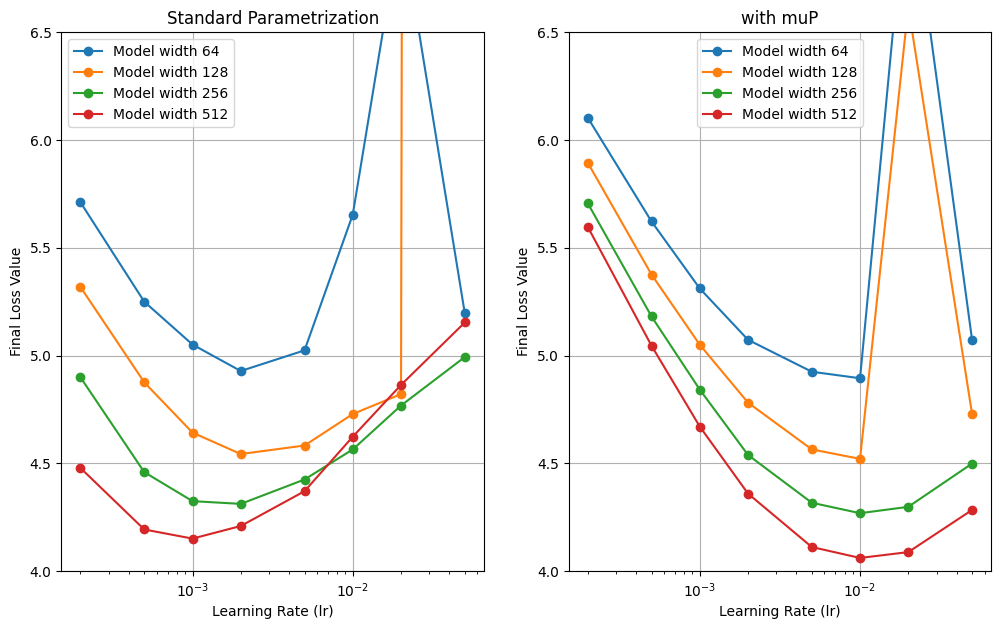

<Figure size 600x700 with 0 Axes>

<Figure size 600x700 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

tags = ["muP_MoE", "muTransfer", "lr_plot_moe"]
# tags = ["muP_MoE", "muTransfer", "kc_reference_grid", "kc_version_3", "like_blog"]

df = get_neptune_table(tags)
print(df.shape)
plot_loss_vs_lr(df, (4, 6.5), figsize=(6, 7), title="Standard Parametrization", ax=axes[0])

tags = ["muP_MoE", "muTransfer", "lr_plot_moe_mup"]
df = get_neptune_table(tags)
print(df.shape)
plot_loss_vs_lr(df, (4, 6.5), figsize=(6, 7), title="with muP", ax=axes[1])
fig.savefig(f'{plots_folder}/lr_plot_moe.pdf')

https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (25, 407)
(25, 407)
run ID: LLMRANDOM-31898, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-31898
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-31897, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-31897
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-31896, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-31896
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-31895, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-31895
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-31894, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-31894
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-31893, last_step: 10.0
https://app.neptun

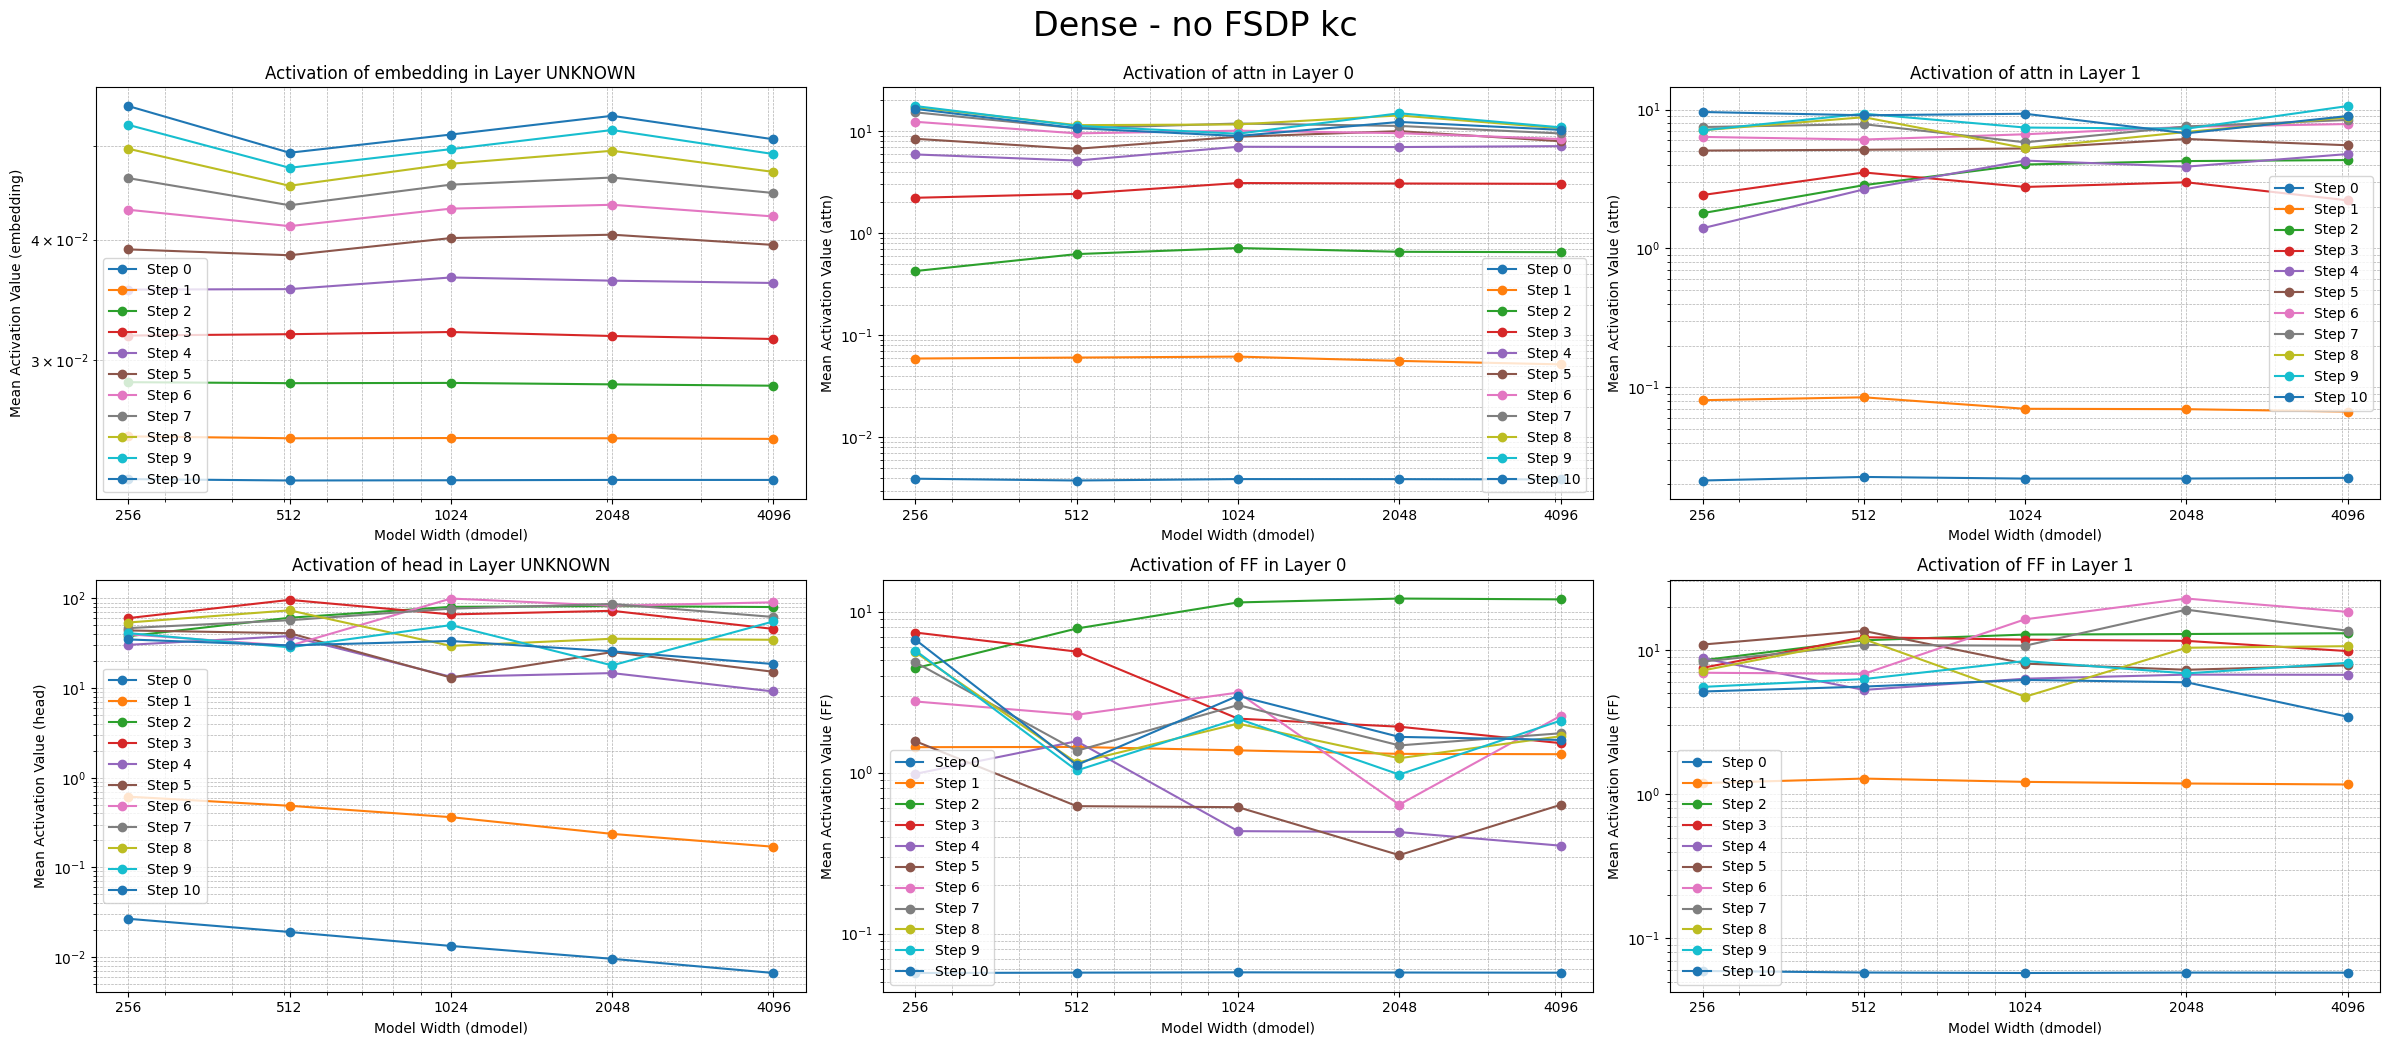

In [4]:
tags = ["muP_MoE", "muTransfer", "old_for_comparison"]
step_plots_from_tags(tags, title="Dense - no FSDP kc", save_to=f'{plots_folder}/dense_no_fsdp_kc.pdf', target_nsteps=10)

https://app.neptune.ai/pmtest/llm-random/


Table downloaded
Shape: (35, 490)
(35, 490)
run ID: LLMRANDOM-31668, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-31668
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-31666, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-31666
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-31665, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-31665
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-31664, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-31664
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-31663, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-31663
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-31662, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-31662
r

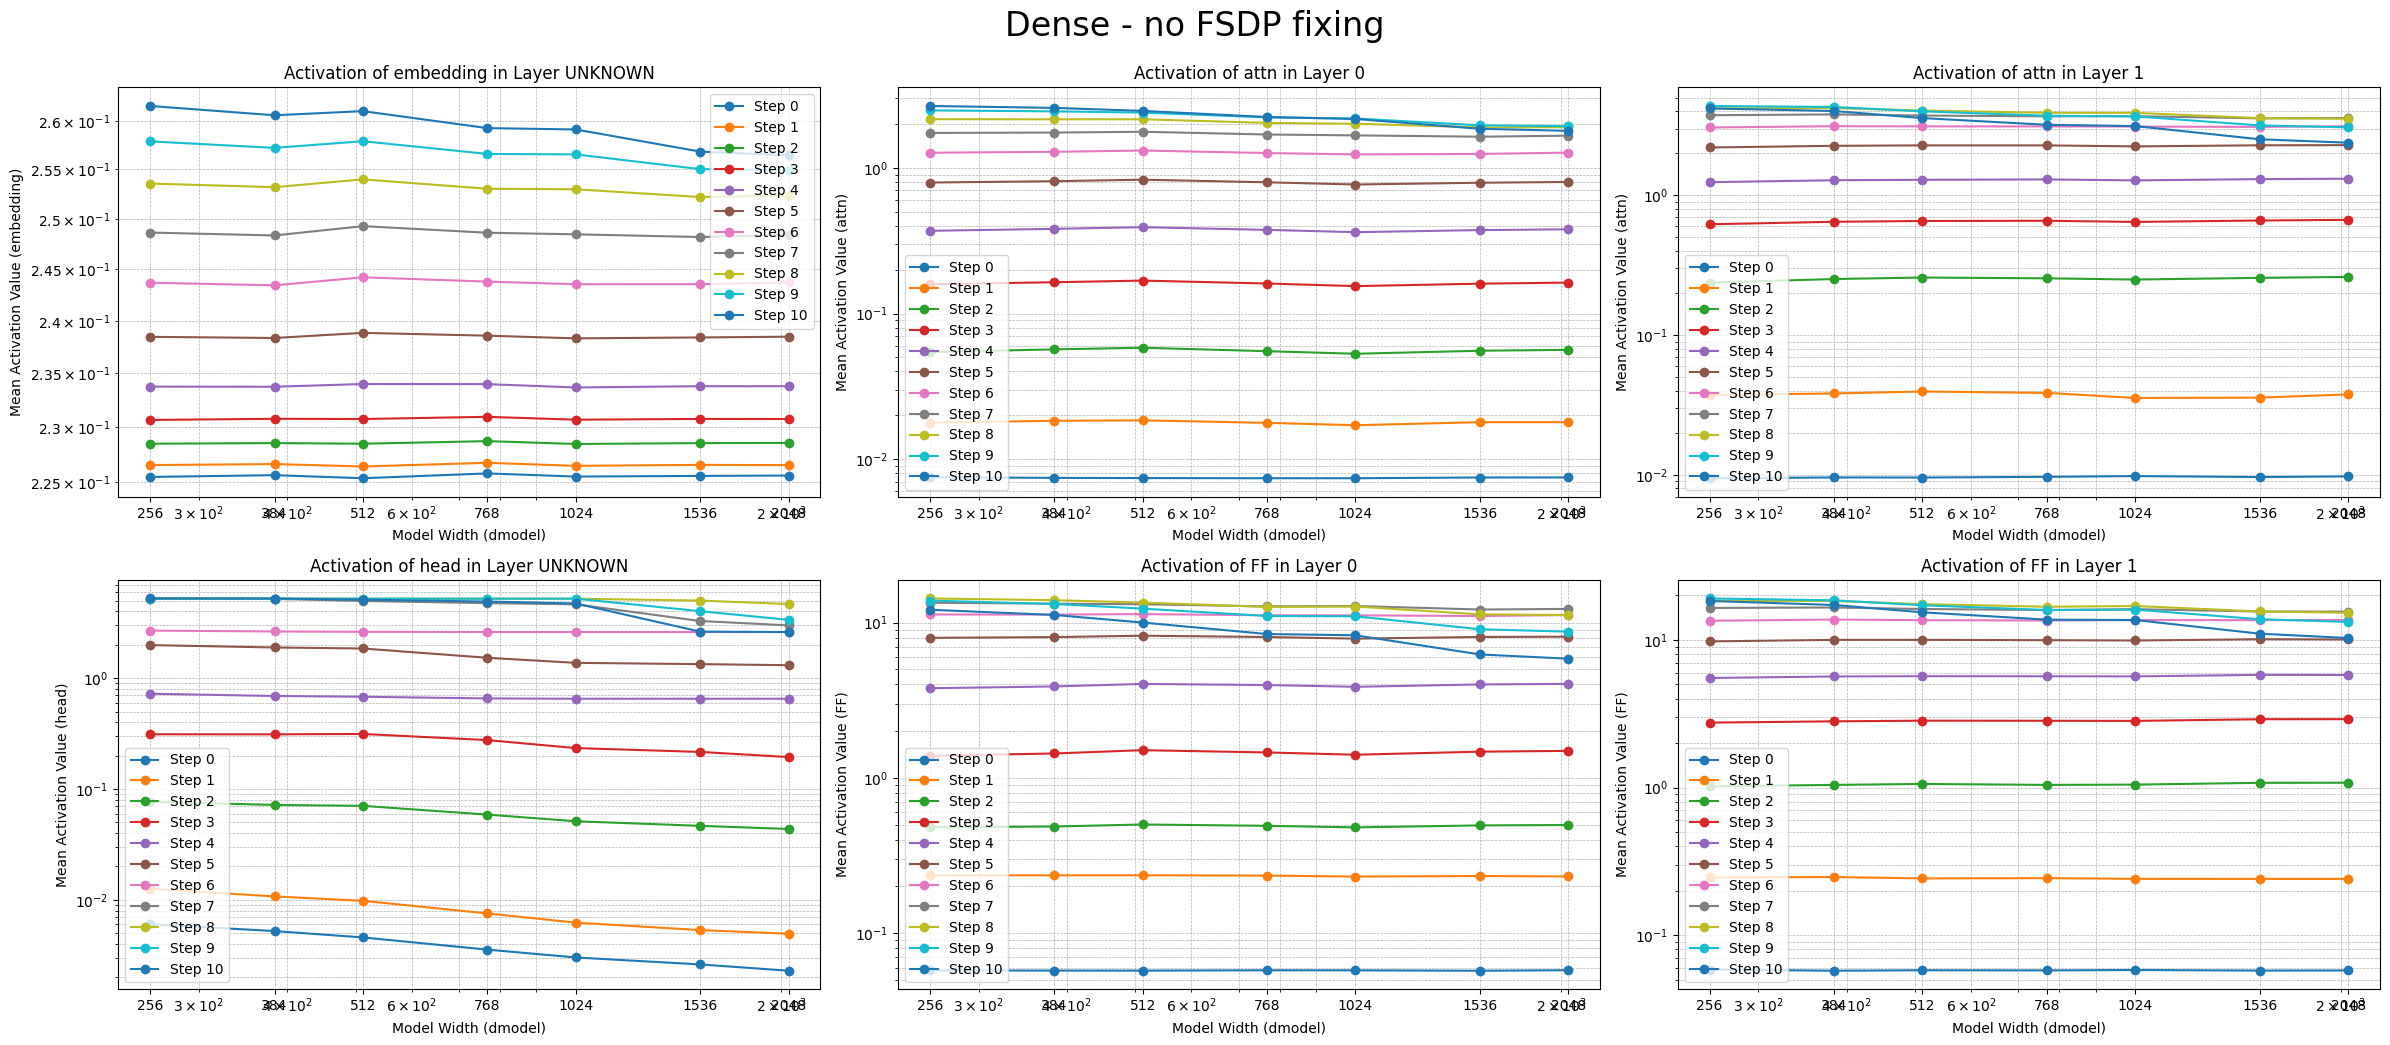

In [7]:
tags = ["muP_MoE", "muTransfer", "10_step_fixing_v3"]
step_plots_from_tags(tags, title="Dense - no FSDP fixing", save_to=f'{plots_folder}/dense_no_fsdp_fixin.pdf', target_nsteps=10)

https://app.neptune.ai/pmtest/llm-random/


Table downloaded
Shape: (18, 347)
(18, 347)
run ID: LLMRANDOM-30884, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30884
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-30883, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30883
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-30881, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30881
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-30880, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30880
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-30879, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30879
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-30873, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30873
r

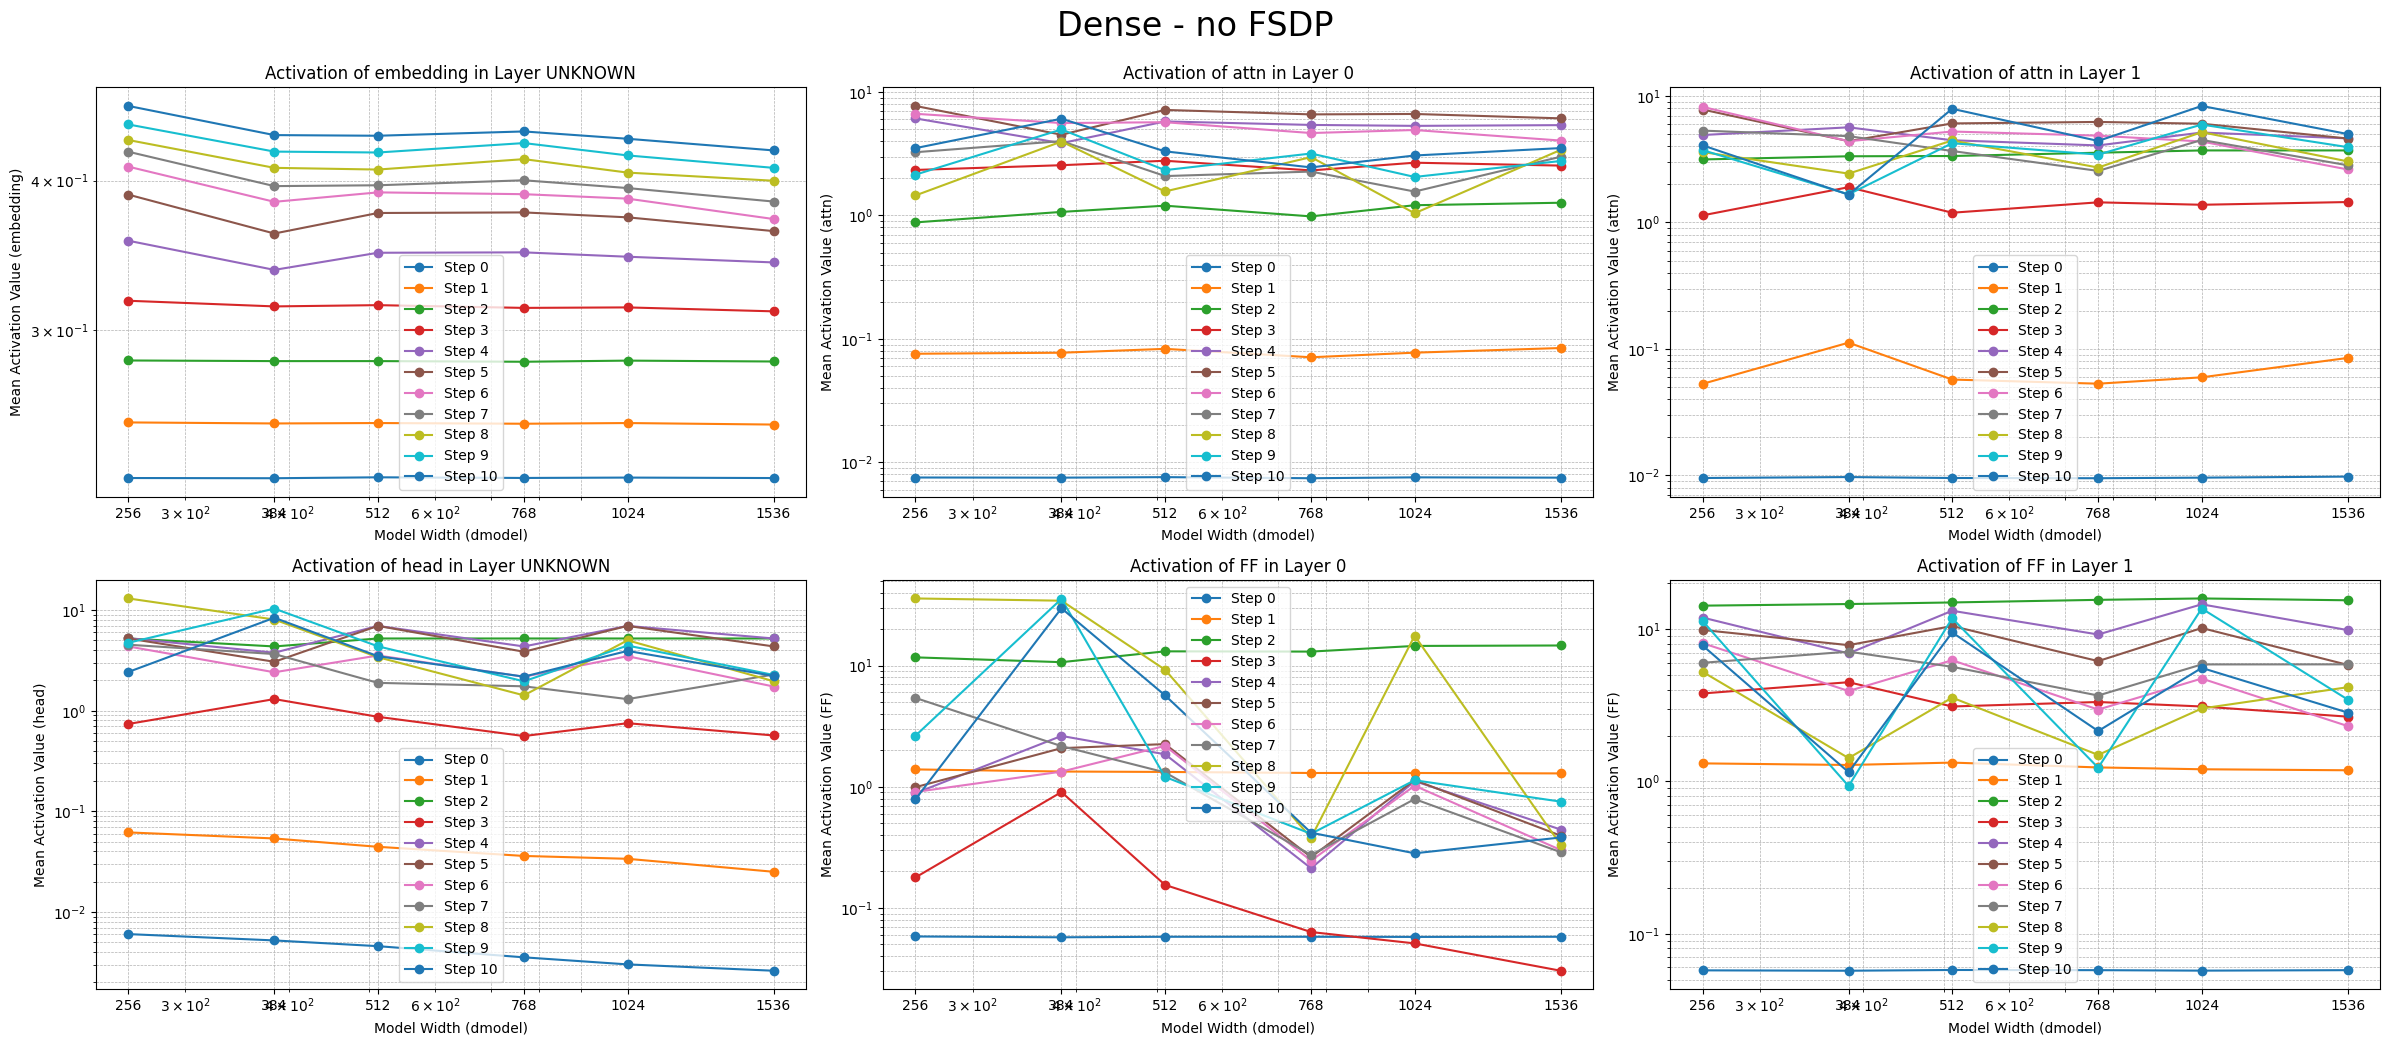

In [ ]:
tags = ["muP_MoE", "muTransfer", "10_step_new", "no_fsdp",]
step_plots_from_tags(tags, title="Dense - no FSDP", save_to=f'{plots_folder}/dense_no_fsdp.pdf')

https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (26, 463)
(26, 463)
run ID: LLMRANDOM-30924, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30924
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
Unexpected error: MissingFieldException - 

----MissingFieldException-------------------------------------------------------

The field "block_UNKNOWN/embedding_layer/muP/mean_abs_update" was not found.

There are two possible reasons:
    - There is a typo in the path. Double-check your code for typos.
    - You are fetching a field that another process created, but the local representation is not synchronized.
    If you are sending metadata from multiple processes at the same time, synchronize the local representation before fetching values:
        run.sync()

Need help?-> https://docs.neptune.ai/getting_help

run ID: LLMRANDOM-30923, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30923
run keys
<Namespace f

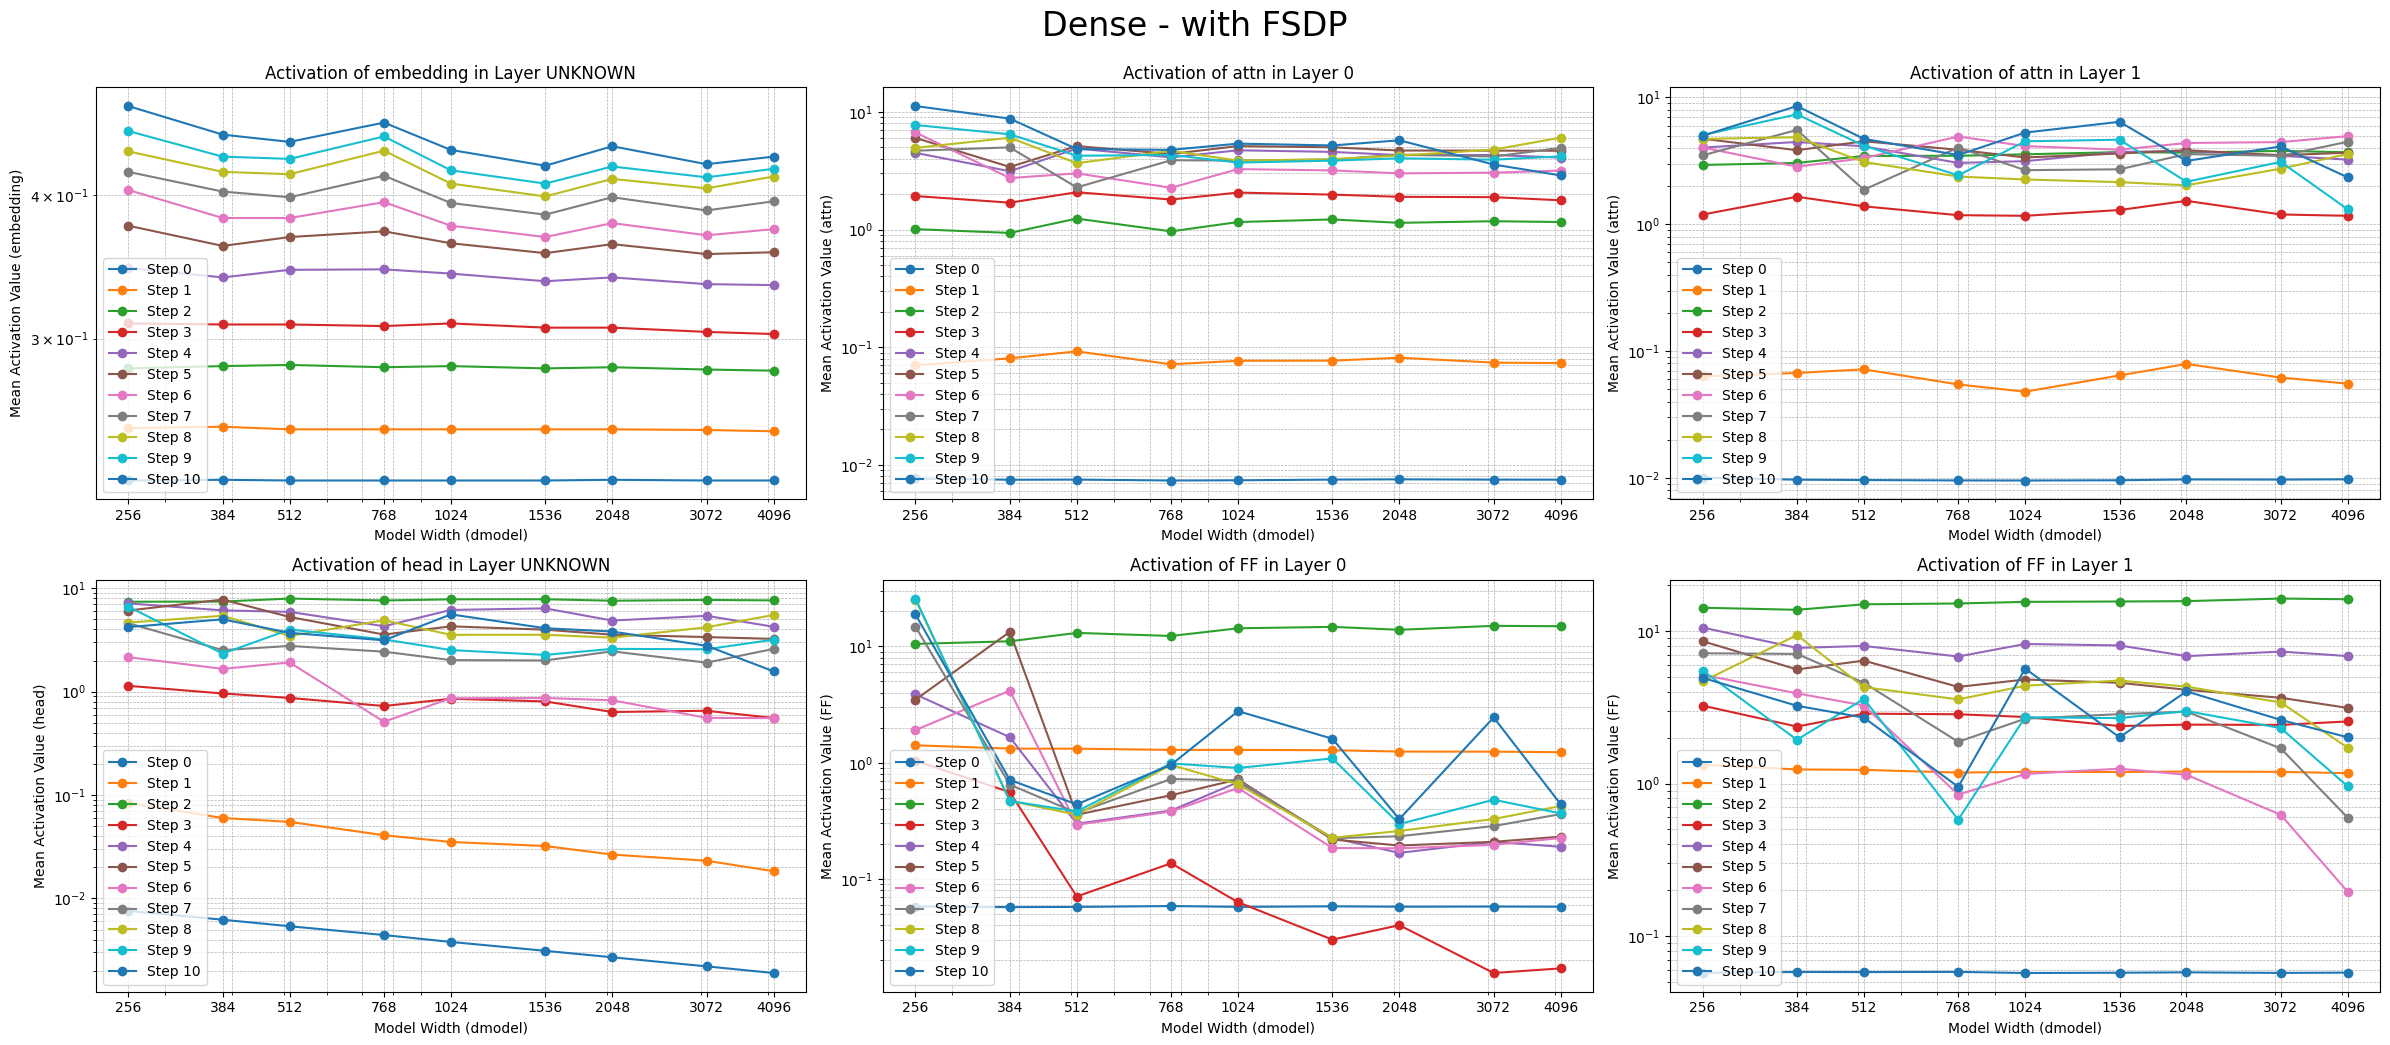

In [ ]:
tags = ["muP_MoE", "muTransfer", "10_step_new", "fsdp",]
step_plots_from_tags(tags, title="Dense - with FSDP", save_to=f'{plots_folder}/dense_with_fsdp.pdf')

https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (18, 363)
(18, 363)
run ID: LLMRANDOM-30917, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30917
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-30913, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30913
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-30912, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30912
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-30911, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30911
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-30910, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30910
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
run ID: LLMRANDOM-30907, last_step: 10.0
https://app.neptun

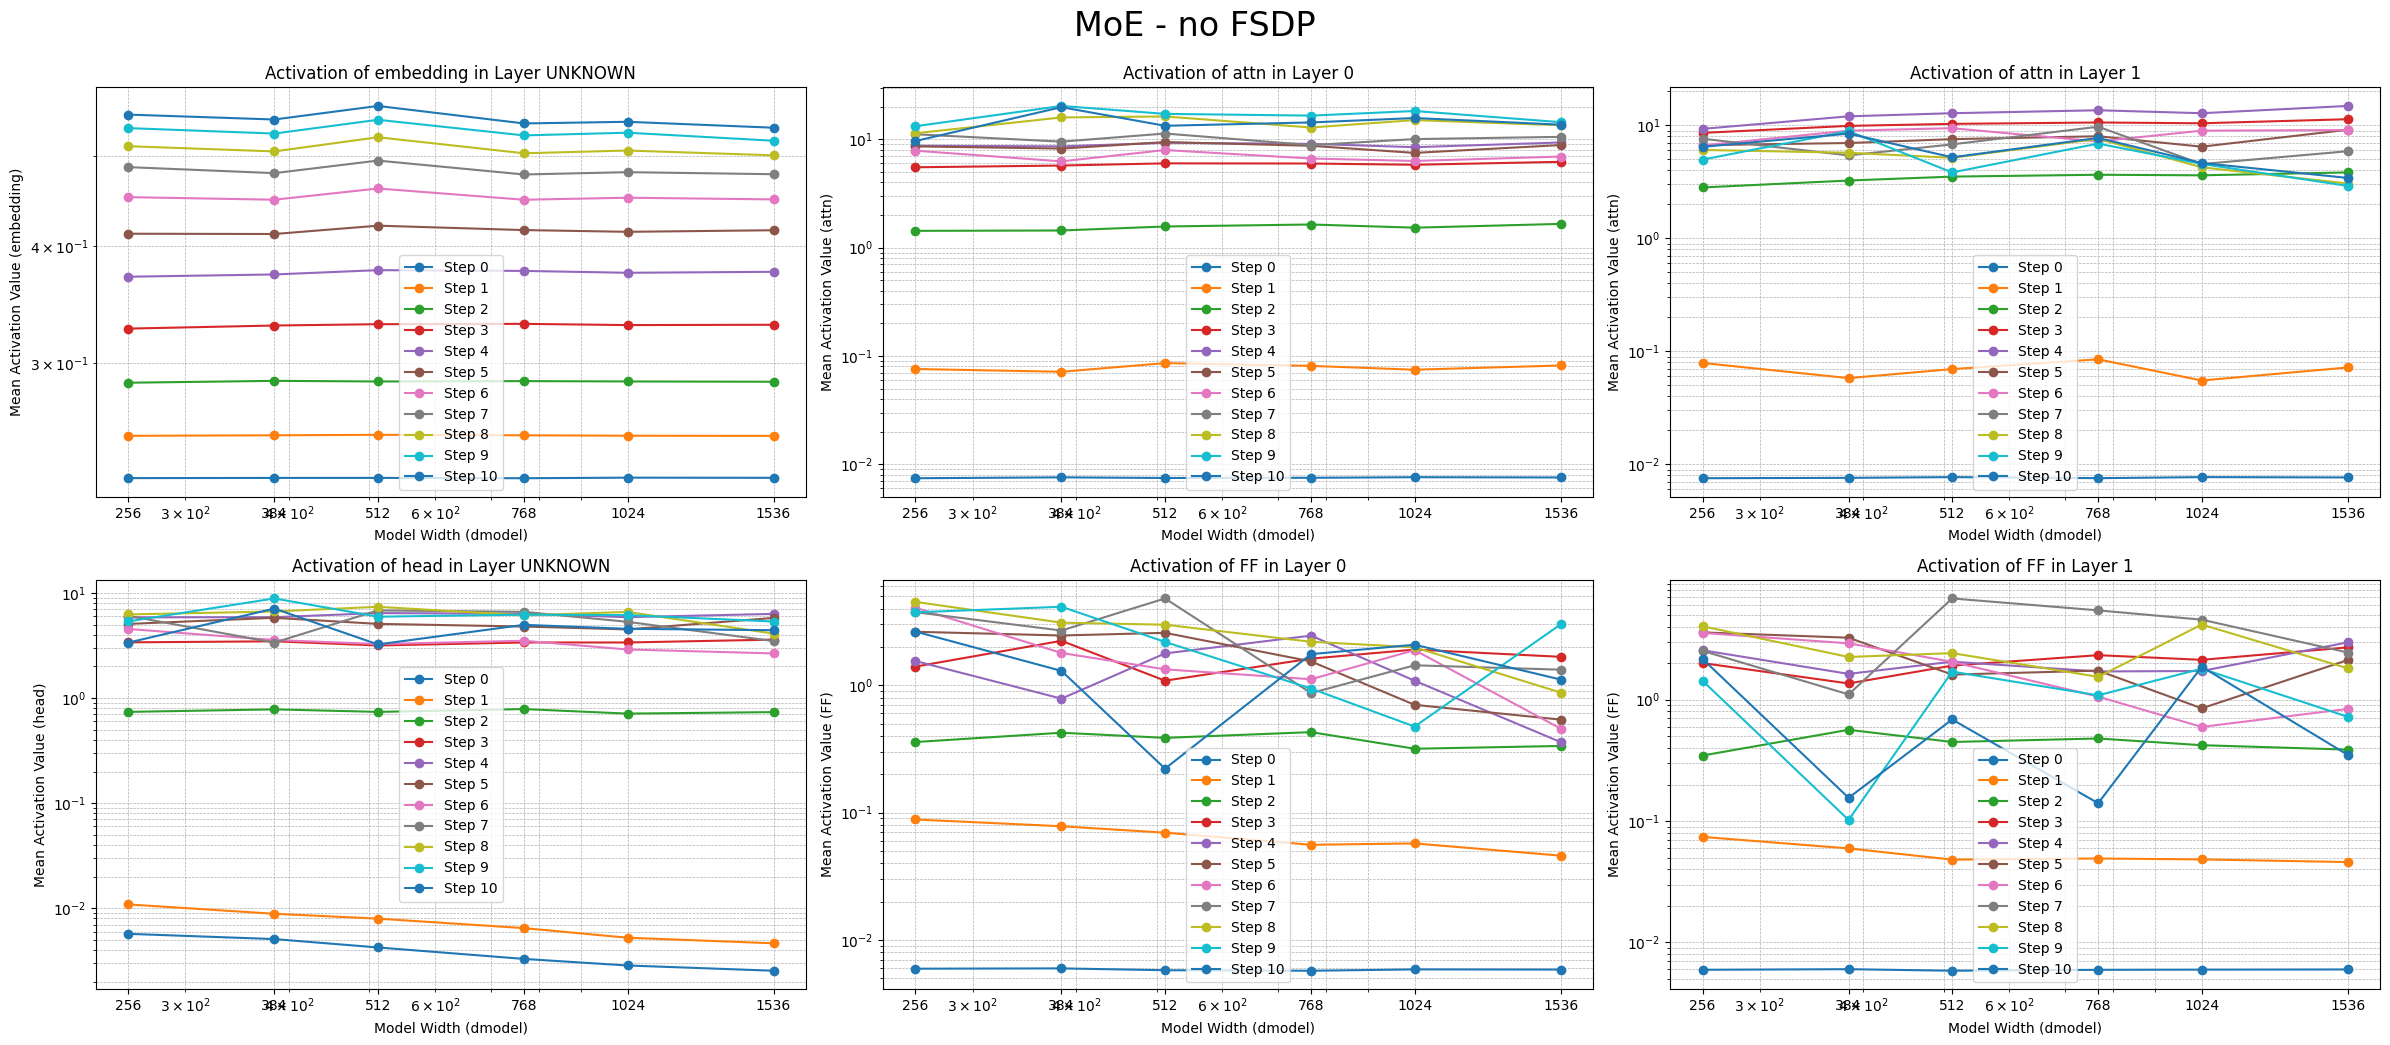

In [ ]:
tags = ["muP_MoE", "muTransfer", "10_step_moe", "no_fsdp",]
step_plots_from_tags(tags, title="MoE - no FSDP", save_to=f'{plots_folder}/moe_no_fsdp.pdf')

https://app.neptune.ai/pmtest/llm-random/
Table downloaded
Shape: (26, 501)
(26, 501)
run ID: LLMRANDOM-30952, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30952
run keys
<Namespace field at "block_0/residual_attention">
n_blocks: 2
Unexpected error: MissingFieldException - 

----MissingFieldException-------------------------------------------------------

The field "block_UNKNOWN/embedding_layer/muP/mean_abs_update" was not found.

There are two possible reasons:
    - There is a typo in the path. Double-check your code for typos.
    - You are fetching a field that another process created, but the local representation is not synchronized.
    If you are sending metadata from multiple processes at the same time, synchronize the local representation before fetching values:
        run.sync()

Need help?-> https://docs.neptune.ai/getting_help

run ID: LLMRANDOM-30951, last_step: 10.0
https://app.neptune.ai/pmtest/llm-random/e/LLMRANDOM-30951
run keys
<Namespace f

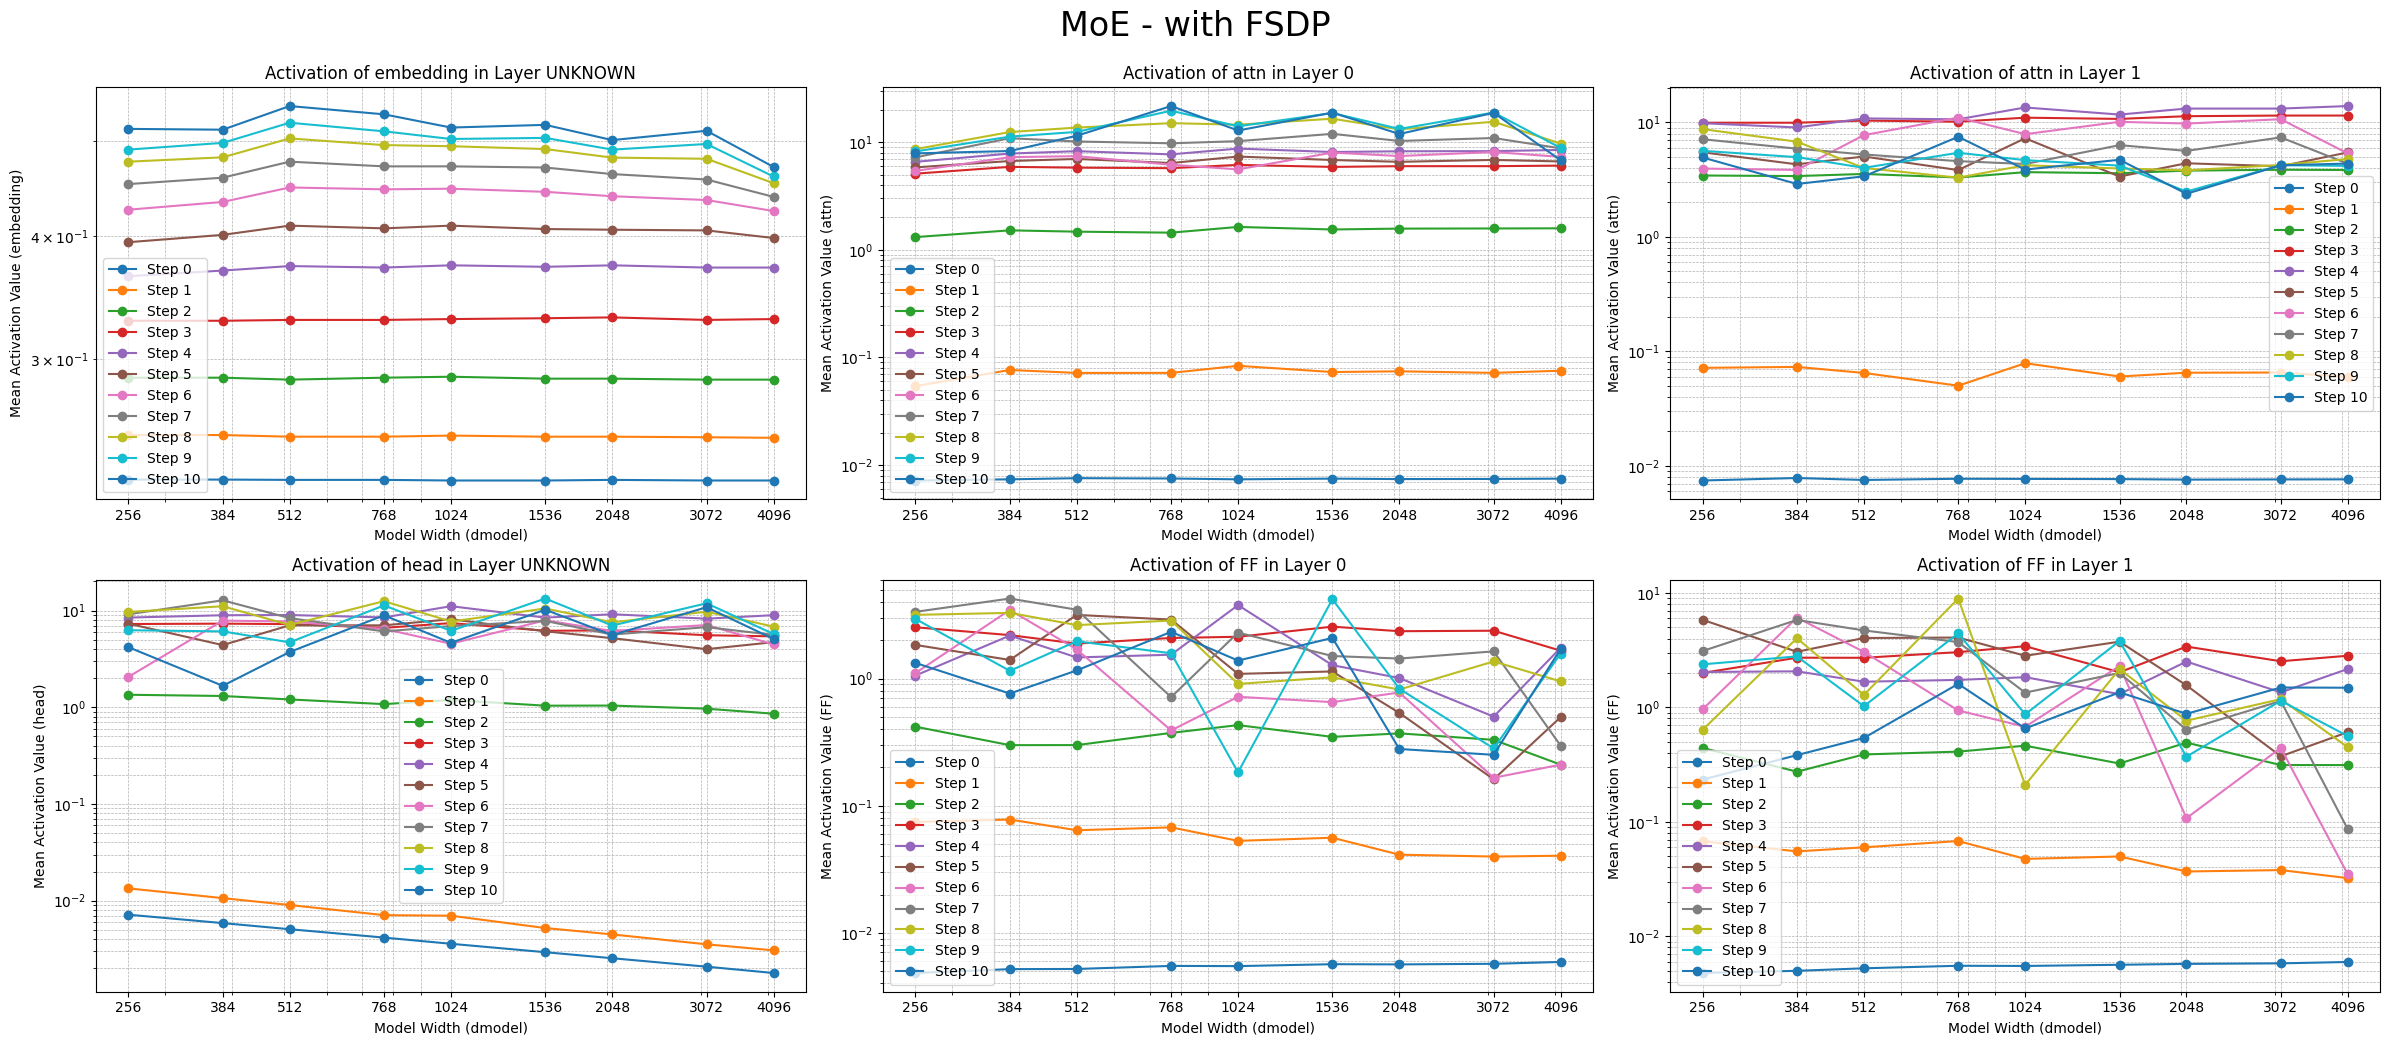

In [ ]:
tags = ["muP_MoE", "muTransfer", "10_step_moe", "fsdp",]
step_plots_from_tags(tags, title="MoE - with FSDP", save_to=f'{plots_folder}/moe_with_fsdp.pdf')